In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier as KNC
from IPython.display import display

### Déclaration des données

In [6]:
arbres = pd.read_csv("train.csv", index_col = 'ID_ARBRE')
arbres_trie = arbres[["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]]
y = arbres[["classification_diagnostic"]]

prev = pd.read_csv("prev.csv", index_col = 'ID_ARBRE')
prev_trie = prev[["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]]

In [7]:
print("Arbres triés")
display(arbres_trie.head(2))
print("Prev triés")
display(prev_trie.head(2))

Arbres triés


,type_sol,classe_age,classe_hauteur,classe_circonference,port_arbre,vigueur_pousse,plaie_collet,fissure_tronc,plaie_tronc,fissure_houppier,bois_mort_houppier,plaie_houppier,esperance_maintien
ID_ARBRE,,,,,,,,,,,,,
0,MA,A,H1,C1,R5,P,RCPPL,TPF,TPLS,HPF,HPBM,HPLS,1.0
1,MA,A,H2,C3,R5,P,RCPLS,TFO,TPLNC,HFO,HPBM,HPLNC,2.0


Prev triés


,type_sol,classe_age,classe_hauteur,classe_circonference,port_arbre,vigueur_pousse,plaie_collet,fissure_tronc,plaie_tronc,fissure_houppier,bois_mort_houppier,plaie_houppier,esperance_maintien
ID_ARBRE,,,,,,,,,,,,,
559,MA,A,H2,C2,R5,P,RCPLS,TPF,TPLS,HPF,HPBM,HPLNC,2.0
560,Gr,JA,H2,C2,L,P,RCPPL,TPF,TPLS,HPF,HPBM,HPLS,1.0


### Preprocessing

In [12]:
cat_features = ["classe_circonference", "classe_age", "classe_hauteur", "plaie_houppier", "plaie_tronc", "plaie_collet", "port_arbre", "fissure_tronc", "fissure_houppier", "bois_mort_houppier"]

noncat_features = ["type_sol", "vigueur_pousse"]

num_features = ["esperance_maintien"]

In [14]:
preprocesseur = ColumnTransformer(
    transformers = [
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), noncat_features),
    ('ord', OrdinalEncoder(), cat_features)],
    remainder = "passthrough"
)

arbres_hot = preprocesseur.fit_transform(arbres_trie)
colonnes = preprocesseur.get_feature_names_out()
arbres_hot = pd.DataFrame(arbres_hot, columns = colonnes)

prev_hot = preprocesseur.transform(prev_trie)
prev_hot = pd.DataFrame(prev_hot, columns = colonnes)

print("Arbres_hot :")
display(arbres_hot.head(3))
print("Prev_hot :")
display(prev_hot.head(3))

Arbres_hot :


,ohe__type_sol_CS,ohe__type_sol_G,ohe__type_sol_GR,ohe__type_sol_Gr,ohe__type_sol_MA,ohe__type_sol_P,ohe__type_sol_S,ohe__type_sol_TV,ohe__vigueur_pousse_D,ohe__vigueur_pousse_MP,...,ord__classe_age,ord__classe_hauteur,ord__plaie_houppier,ord__plaie_tronc,ord__plaie_collet,ord__port_arbre,ord__fissure_tronc,ord__fissure_houppier,ord__bois_mort_houppier,remainder__esperance_maintien
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,3.0,6.0,2.0,2.0,2.0,2.0,1.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,2.0,5.0,2.0,1.0,1.0,2.0,2.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,6.0,2.0,2.0,2.0,2.0,1.0


Prev_hot :


,ohe__type_sol_CS,ohe__type_sol_G,ohe__type_sol_GR,ohe__type_sol_Gr,ohe__type_sol_MA,ohe__type_sol_P,ohe__type_sol_S,ohe__type_sol_TV,ohe__vigueur_pousse_D,ohe__vigueur_pousse_MP,...,ord__classe_age,ord__classe_hauteur,ord__plaie_houppier,ord__plaie_tronc,ord__plaie_collet,ord__port_arbre,ord__fissure_tronc,ord__fissure_houppier,ord__bois_mort_houppier,remainder__esperance_maintien
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,3.0,5.0,2.0,2.0,2.0,2.0,2.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,1.0,2.0,3.0,6.0,1.0,2.0,2.0,2.0,1.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,2.0,3.0,5.0,2.0,2.0,2.0,2.0,2.0


### Encodage manuel

In [17]:
import pandas as pd

for col in arbres_trie.columns:
    # Récupérer la liste des valeurs autorisées dans prev pour la colonne col
    valeurs_autorisees = set(prev[col].unique())
    # Supprimer dans arbres_trie les lignes dont la valeur n'est pas dans valeurs_autorisees
    arbres_trie = arbres_trie[arbres_trie[col].isin(valeurs_autorisees)]

In [19]:
colonnes = arbres_trie.columns
for i in colonnes:
    print(i, ":", np.unique(arbres_trie[i]),",")

type_sol : ['CS' 'G' 'GR' 'Gr' 'MA' 'P' 'S'] ,
classe_age : ['A' 'J' 'JA'] ,
classe_hauteur : ['H1' 'H2' 'H3' 'H4'] ,
classe_circonference : ['C1' 'C2' 'C3' 'C4'] ,
port_arbre : ['A' 'L' 'R5' 'SL'] ,
vigueur_pousse : ['MP' 'P' 'PP'] ,
plaie_collet : ['RCPLC' 'RCPLNC' 'RCPLS' 'RCPPL'] ,
fissure_tronc : ['TPF'] ,
plaie_tronc : ['TPLC' 'TPLNC' 'TPLS' 'TPPL'] ,
fissure_houppier : ['HPF '] ,
bois_mort_houppier : ['HBMI ' 'HPBM '] ,
plaie_houppier : ['HPLNC' 'HPLS' 'HPPL'] ,
esperance_maintien : [1. 2. 3.] ,


In [21]:
colonnes_prev = prev_trie.columns
for j in colonnes_prev:
    print(j, ":", np.unique(prev_trie[j]),",")

type_sol : ['CS' 'G' 'GR' 'Gr' 'MA' 'P' 'S'] ,
classe_age : ['A' 'J' 'JA'] ,
classe_hauteur : ['H1' 'H2' 'H3' 'H4'] ,
classe_circonference : ['C1' 'C2' 'C3' 'C4'] ,
port_arbre : ['A' 'L' 'R5' 'SL'] ,
vigueur_pousse : ['MP' 'P' 'PP'] ,
plaie_collet : ['RCPLC' 'RCPLNC' 'RCPLS' 'RCPPL'] ,
fissure_tronc : ['TFF' 'TPF'] ,
plaie_tronc : ['TPLC' 'TPLNC' 'TPLS' 'TPPL'] ,
fissure_houppier : ['HFF ' 'HPF '] ,
bois_mort_houppier : ['HBMI ' 'HPBM '] ,
plaie_houppier : ['HPLNC' 'HPLS' 'HPPL'] ,
esperance_maintien : [1. 2. 3. 4.] ,


In [23]:
np.unique(prev["plaie_collet"])

array(['RCPLC', 'RCPLNC', 'RCPLS', 'RCPPL'], dtype=object)

In [25]:
ordre_categories = {
    classe_age : ['A', 'AM', 'J', 'JA'] ,
    classe_hauteur : ['H1', 'H2', 'H3', 'H4', 'H5'] ,
    classe_circonference : ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7'] ,
    vigueur_pousse : ['PP', 'P', 'MP', 'D'] ,
    plaie_collet : ['RCPPL', 'RCPLS', 'RCPLC', 'RCPLNC'] ,
    fissure_tronc : ['TPF', 'TFF'] ,
    plaie_tronc : ['TPLC' 'TPLCF' 'TPLNC' 'TPLS' 'TPPL' 'ZZ'] ,
    fissure_houppier : ['HFF ' 'HFO ' 'HPF '] ,
    bois_mort_houppier : ['HBMI ' 'HBMU ' 'HPBM '] ,
    plaie_houppier : ['HPLC' 'HPLNC' 'HPLS' 'HPPL' 'ZZ'] ,
    esperance_maintien : [1. 2. 3. 4.] ,
    
}

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1425586532.py, line 12)

### Divisions en X_train, X_test, Y_train, Y_test

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(arbres_hot, y, test_size=0.10)

In [33]:
print("X_train :")
display(X_train.head(2))
print("X_test :")
display(X_test.head(2))

X_train :


,ohe__type_sol_CS,ohe__type_sol_G,ohe__type_sol_GR,ohe__type_sol_Gr,ohe__type_sol_MA,ohe__type_sol_P,ohe__type_sol_S,ohe__type_sol_TV,ohe__vigueur_pousse_D,ohe__vigueur_pousse_MP,...,ord__classe_age,ord__classe_hauteur,ord__plaie_houppier,ord__plaie_tronc,ord__plaie_collet,ord__port_arbre,ord__fissure_tronc,ord__fissure_houppier,ord__bois_mort_houppier,remainder__esperance_maintien
397,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,1.0,2.0,4.0,6.0,1.0,2.0,2.0,2.0,1.0
415,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,6.0,2.0,2.0,2.0,2.0,1.0


X_test :


,ohe__type_sol_CS,ohe__type_sol_G,ohe__type_sol_GR,ohe__type_sol_Gr,ohe__type_sol_MA,ohe__type_sol_P,ohe__type_sol_S,ohe__type_sol_TV,ohe__vigueur_pousse_D,ohe__vigueur_pousse_MP,...,ord__classe_age,ord__classe_hauteur,ord__plaie_houppier,ord__plaie_tronc,ord__plaie_collet,ord__port_arbre,ord__fissure_tronc,ord__fissure_houppier,ord__bois_mort_houppier,remainder__esperance_maintien
251,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,3.0,3.0,6.0,3.0,2.0,2.0,2.0,3.0
319,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,2.0,0.0,1.0,2.0,2.0,2.0,2.0,1.0


### Entrainement modèle

In [36]:
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import KFold, StratifiedKFold

In [38]:
model = KNC(n_neighbors = 2, metric='manhattan')

In [41]:
model.fit(X_train, Y_train["classification_diagnostic"])

KNeighborsClassifier(metric='manhattan', n_neighbors=2)

In [43]:
model.score(X_test, Y_test)

0.9090909090909091

In [44]:
previsions_sklearn = model.predict(prev_hot)
previsions_sklearn

array(['C2', 'C2', 'C2', 'C1', 'C3', 'C2', 'C1', 'C1', 'C1', 'C2', 'C5',
       'C2', 'C2', 'C2', 'C1', 'C1', 'C2', 'C2', 'C2', 'C2', 'C2', 'C3',
       'C1', 'C2', 'C1', 'C2', 'C1', 'C2', 'C1', 'C2', 'C2', 'C1', 'C2',
       'C2', 'C2', 'C2', 'C2', 'C1', 'C2', 'C2', 'C1', 'C2', 'C1', 'C2',
       'C2', 'C1', 'C1', 'C2', 'C2', 'C2', 'C1', 'C1', 'C1', 'C2', 'C2',
       'C1', 'C2', 'C1', 'C2', 'C2', 'C2', 'C1', 'C1', 'C1', 'C2', 'C2',
       'C2', 'C1', 'C2', 'C1', 'C3', 'C1', 'C1', 'C2', 'C2', 'C1', 'C2',
       'C1', 'C1', 'C1', 'C2', 'C2', 'C2', 'C2', 'C1', 'C1', 'C2', 'C2',
       'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C2', 'C2', 'C1', 'C1', 'C2',
       'C1', 'C2', 'C1', 'C3', 'C1', 'C1', 'C1', 'C2', 'C1', 'C2', 'C2',
       'C2', 'C2', 'C1', 'C2', 'C2', 'C2', 'C1', 'C1', 'C2', 'C2', 'C2',
       'C2', 'C2', 'C1', 'C1', 'C2', 'C1', 'C1', 'C1', 'C2', 'C2', 'C1',
       'C2', 'C3', 'C2', 'C1', 'C1'], dtype=object)

In [47]:
cv = KFold(10)

In [49]:
cross_validation_train = [cross_val_score(KNC(k, metric='minkowski', p=2), arbres_hot, y["classification_diagnostic"], cv=cv).mean() for k in range(1, 21)]

In [50]:
cross_validation_test = [cross_val_score(KNC(k, metric='minkowski', p=2), X_train, Y_train["classification_diagnostic"], cv=cv).mean() for k in range(1, 21)]

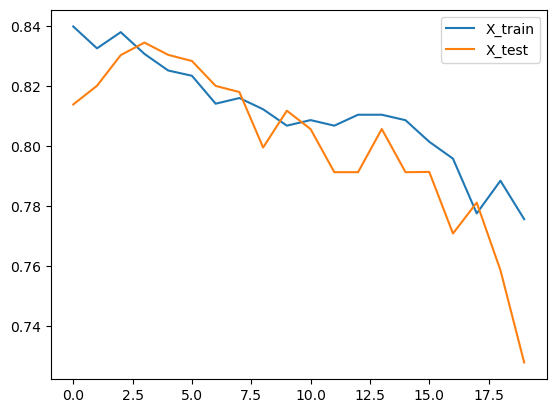

In [51]:
plt.plot(cross_validation_train, label="X_train")
plt.plot(cross_validation_test, label="X_test")
plt.legend()

### GridSearchCV

In [195]:
from sklearn.model_selection import GridSearchCV

In [387]:
grid = {
    'metric' : ['euclidean', 'manhattan', 'cityblock', 'cosine', 'l1'],
    'n_neighbors' : [2, 3, 4, 5, 6, 7, 9],
}

In [205]:
GridSearch = GridSearchCV(KNC(), grid, cv = KFold(7))
best_score = 0;
best_part = 0;
scores = []

for part in np.arange(0.1, 0.5, 0.1):
    X_train2, X_test2, Y_train2, Y_test2 = train_test_split(arbres_hot, y, test_size=part) 
    GridSearch.fit(X_train2, Y_train2["classification_diagnostic"])
    best_knn = GridSearch.best_estimator_
    score = best_knn.score(X_test, Y_test)
    scores.append(score)
    if best_score < score:
        best_score = score
        best_part = part

In [219]:
best_part

0.1

In [389]:
GridSearch.fit(X_train, Y_train["classification_diagnostic"])

GridSearchCV(cv=KFold(n_splits=7, random_state=None, shuffle=False),
             estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [2, 3, 4, 5, 6, 7, 9]})

In [391]:
best_knn = GridSearch.best_estimator_
best_knn

KNeighborsClassifier(metric='manhattan')

In [393]:
grid_pred = best_knn.predict(prev_hot)
best_knn.score(X_test, Y_test)

0.8545454545454545

In [290]:
grid_pred

array(['C2', 'C2', 'C2', 'C1', 'C4', 'C2', 'C1', 'C1', 'C1', 'C2', 'C5',
       'C2', 'C2', 'C2', 'C1', 'C1', 'C2', 'C2', 'C1', 'C2', 'C2', 'C4',
       'C1', 'C2', 'C1', 'C2', 'C1', 'C2', 'C1', 'C1', 'C2', 'C1', 'C2',
       'C2', 'C2', 'C2', 'C2', 'C1', 'C2', 'C2', 'C2', 'C2', 'C1', 'C2',
       'C2', 'C1', 'C1', 'C2', 'C2', 'C2', 'C1', 'C1', 'C1', 'C2', 'C2',
       'C1', 'C2', 'C1', 'C2', 'C2', 'C2', 'C1', 'C1', 'C1', 'C2', 'C1',
       'C2', 'C2', 'C2', 'C1', 'C3', 'C1', 'C1', 'C2', 'C2', 'C1', 'C2',
       'C1', 'C1', 'C1', 'C2', 'C2', 'C2', 'C2', 'C1', 'C1', 'C1', 'C2',
       'C1', 'C2', 'C1', 'C1', 'C1', 'C1', 'C2', 'C2', 'C1', 'C1', 'C2',
       'C1', 'C2', 'C1', 'C4', 'C1', 'C1', 'C1', 'C2', 'C1', 'C2', 'C1',
       'C2', 'C2', 'C1', 'C2', 'C2', 'C2', 'C1', 'C1', 'C2', 'C2', 'C2',
       'C2', 'C2', 'C1', 'C1', 'C2', 'C2', 'C1', 'C1', 'C2', 'C2', 'C1',
       'C2', 'C3', 'C2', 'C1', 'C1'], dtype=object)

### Submition

In [283]:
sub = pd.DataFrame({'classification_diagnostic': grid_pred})
sub.index.name = "ID_ARBRE"
id_arbre = prev_trie.index  # On récupère l'index chez x2
sub["ID_ARBRE"] = id_arbre  # Ajoute l'index comme colonne
sub = sub.set_index("ID_ARBRE")  # On définie 'ID_ARBRE' en tant qu'index

In [285]:
sub.to_csv("sub_gridsearch3.csv")

In [262]:
sub.head()

,classification_diagnostic
ID_ARBRE,
559,C2
560,C2
561,C2
562,C1
563,C4
